In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Input file (with or without .npz extension)
FILENAME = "full16"

# Input keys to include in the stack plot (up to 12 requested)
KEYS_TO_PLOT = [
    "Bacteroidaceae",
    "Bifidobacteriaceae",
    "Enterobacteriaceae",
    "Lachnospiraceae",
    "Muribaculaceae",
    "Oscillospiraceae",
    "Prevotellaceae",
    "Ruminococcaceae",
    "Sutterellaceae",
    "Synergistaceae",
    "Tannerellaceae",
    "Other_bacteria",
]

IDX_TO_NAME = {
    0:'Bacteroidaceae',
    3:'Lachnospiraceae',
    2:'Enterobacteriaceae',
    9:'Synergistaceae',
    6:'Prevotellaceae',
    7:'Ruminococcaceae',
    4:'Muribaculaceae',
    5:'Oscillospiraceae',
    8:'Sutterellaceae',
    10:'Tannerellaceae',
    1:'Bifidobacteriaceae',
    11:'Rest',
}

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "mocks" and (PROJECT_ROOT.parent / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "pyproject.toml").exists() and (PROJECT_ROOT.parent / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BASE_DIR = PROJECT_ROOT / "output_files" / "tracked_simulations"
STACK_COLORS = list(plt.get_cmap("tab20").colors[:12])

In [2]:
font = {'family' : 'Lucida Console',
        'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

In [3]:
matplotlib.font_manager.get_font_names()

['DejaVu Sans Display',
 'GDT_IV50',
 'GreekS',
 'SimSun',
 'Complex',
 'Symath',
 'GreekC',
 'Palatino Linotype',
 'STIXSizeFiveSym',
 'ScriptS',
 'Constantia',
 'STIXSizeOneSym',
 'Webdings',
 'Segoe UI Emoji',
 'cmss10',
 'GDT_IV25',
 'AcadEref',
 'Nirmala UI',
 'Microsoft PhagsPa',
 'GOST Common',
 'Courier New',
 'Segoe MDL2 Assets',
 'Yu Gothic',
 'cmex10',
 'ISOCTEUR',
 'Simplex',
 'ISOCP',
 'Mongolian Baiti',
 'cmmi10',
 'Yu Mincho',
 'ISOCT3',
 'Gabriola',
 'STIXNonUnicode',
 'Monotxt',
 'Microsoft New Tai Lue',
 'Corbel',
 'RomanS',
 'GENISO',
 'Consolas',
 'Leelawadee UI',
 'ISOCP3',
 'DejaVu Serif',
 'Lato',
 'SimSun-ExtG',
 'Ebrima',
 'Cambria',
 'Meiryo',
 'UD Digi Kyokasho N-B',
 'Lucida Console',
 'Txt',
 'Lucida Sans Unicode',
 'AMGDT',
 'STIXSizeThreeSym',
 'Symusic',
 'Franklin Gothic Medium',
 'DejaVu Serif Display',
 'Arial',
 'STIXSizeFourSym',
 'Tahoma',
 'Symeteo',
 'ISOCT',
 'SimSun-ExtB',
 'Myanmar Text',
 'MS Mincho',
 'Microsoft Himalaya',
 'AIGDT',
 'Ink Fr

In [4]:
def resolve_npz_path(filename: str) -> Path:
    candidate = Path(filename)
    if candidate.suffix != ".npz":
        candidate = candidate.with_suffix(".npz")

    if candidate.exists():
        return candidate

    fallback = BASE_DIR / candidate.name
    if fallback.exists():
        return fallback

    raise FileNotFoundError(f"Could not find file: {candidate} or {fallback}")


npz_path = resolve_npz_path(FILENAME)
print(f"Loading: {npz_path}")

with np.load(npz_path) as raw:
    metadata = {}
    if "__state_tracker_metadata__" in raw.files:
        metadata = json.loads(str(raw["__state_tracker_metadata__"].item()))

    tracked = {
        k: raw[k].copy()
        for k in raw.files
        if k != "__state_tracker_metadata__"
    }

available_keys = list(tracked.keys())
print("Available keys:", available_keys)

missing = [k for k in KEYS_TO_PLOT if k not in tracked]
if missing:
    raise KeyError(f"These requested keys are missing in file: {missing}")

# Keep only requested keys that exist, in user-provided order.
selected_keys = [k for k in KEYS_TO_PLOT if k in tracked]

if len(selected_keys) == 0:
    raise ValueError("No keys selected for plotting.")

if len(selected_keys) > 12:
    raise ValueError("Please provide at most 12 keys for this plot.")

key_layers = {}
if metadata:
    keys_meta = metadata.get("keys", [])
    layers_meta = metadata.get("key_layers", [])
    key_layers = {k: int(v) for k, v in zip(keys_meta, layers_meta)}

print("Selected keys:", selected_keys)

Loading: d:\2studiowanie\sem2\Magisterka\Cellular-Automata\output_files\tracked_simulations\full16.npz
Available keys: ['substrate', 'biofilm', 'Bacteroidaceae', 'Lachnospiraceae', 'Enterobacteriaceae', 'Synergistaceae', 'Prevotellaceae', 'Ruminococcaceae', 'Muribaculaceae', 'Oscillospiraceae', 'Sutterellaceae', 'Tannerellaceae', 'Bifidobacteriaceae', 'Other_bacteria']
Selected keys: ['Bacteroidaceae', 'Bifidobacteriaceae', 'Enterobacteriaceae', 'Lachnospiraceae', 'Muribaculaceae', 'Oscillospiraceae', 'Prevotellaceae', 'Ruminococcaceae', 'Sutterellaceae', 'Synergistaceae', 'Tannerellaceae', 'Other_bacteria']


In [28]:
tracked['substrate'].shape

(1249, 50, 50, 10, 6)

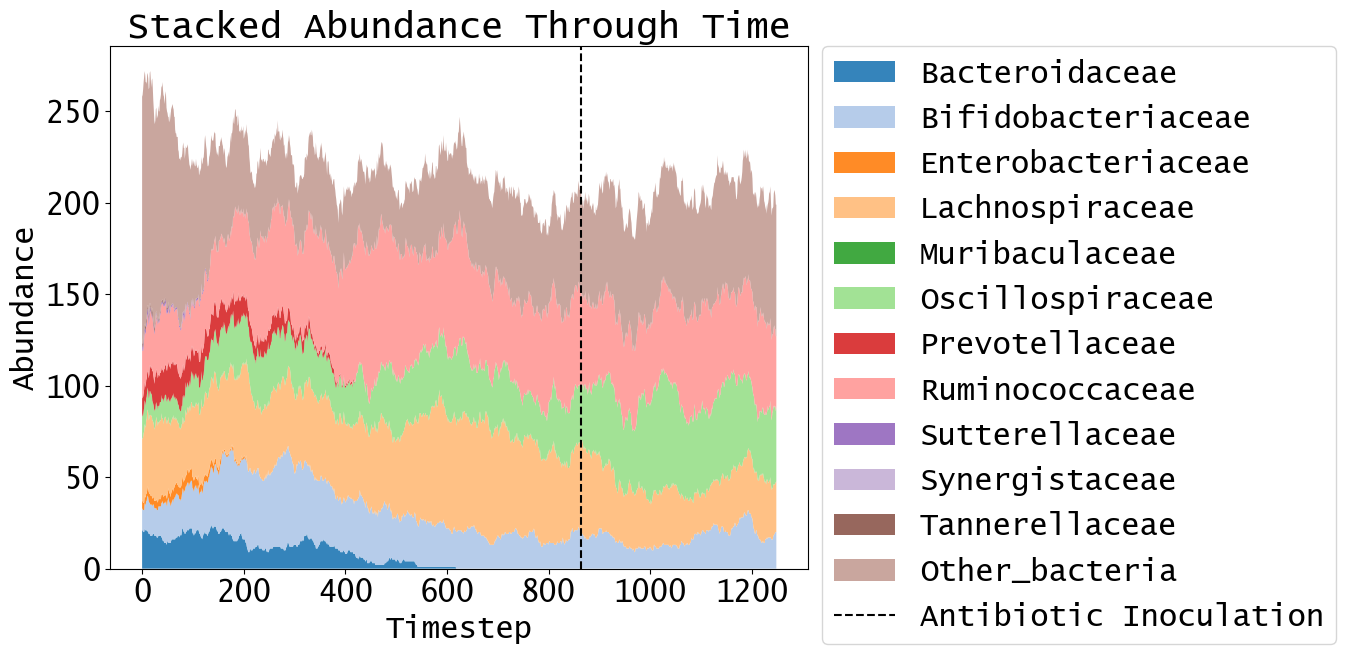

In [5]:
def key_abundance_over_time(arr: np.ndarray, layers: int | None = None) -> np.ndarray:
    """
    arr shape from tracker is typically:
    - no layers: (time, x, y, z)
    - with layers: (time, x, y, z, layers)

    Abundance per timestep = number of spatial cells where value != 0.
    For multi-layer keys, a cell is counted once if ANY layer is non-zero.
    """
    if arr.ndim < 2:
        raise ValueError(f"Expected time + spatial dimensions, got shape {arr.shape}")

    if layers is not None and layers > 1:
        cell_nonzero = np.any(arr != 0, axis=-1)
    else:
        # Fallback for older files without metadata: if rank suggests a layer axis,
        # collapse the last axis to count spatial cells once.
        if layers is None and arr.ndim >= 5:
            cell_nonzero = np.any(arr != 0, axis=-1)
        else:
            cell_nonzero = arr != 0

    # Flatten spatial dims and count non-zero cells for each timestep.
    return cell_nonzero.reshape(cell_nonzero.shape[0], -1).sum(axis=1)


abundance_series = []
for key in selected_keys:
    arr = tracked[key]
    abundance_series.append(key_abundance_over_time(arr, key_layers.get(key)))

abundance_matrix = np.vstack(abundance_series)
time = np.arange(abundance_matrix.shape[1])

plt.figure(figsize=(14, 7))
plt.stackplot(
    time,
    abundance_matrix,
    labels=selected_keys,
    alpha=0.9,
    colors=STACK_COLORS[:len(selected_keys)],
)
plt.axvline(864, color="black", linestyle="--", linewidth=1.5, label="Antibiotic Inoculation") #864 , 85
plt.title("Stacked Abundance Through Time")
plt.xlabel("Timestep")
plt.ylabel("Abundance")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()

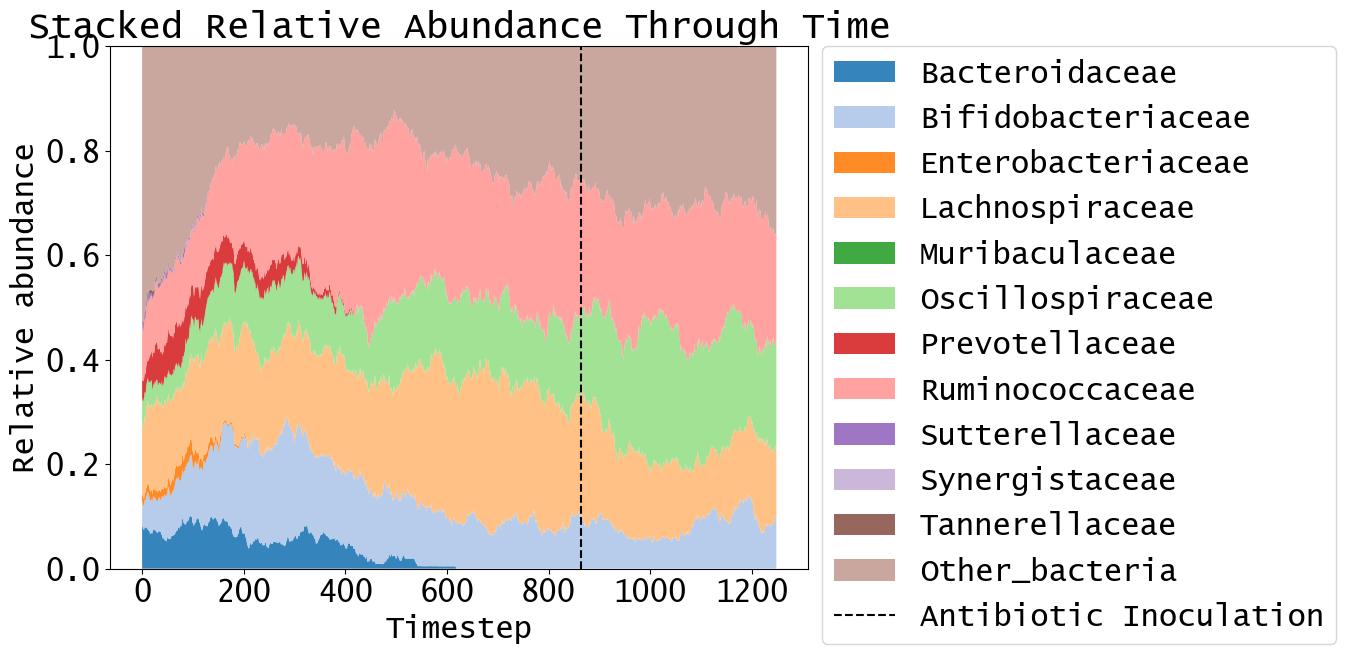

In [6]:
relative_totals = abundance_matrix.sum(axis=0, keepdims=True)
relative_totals = np.where(relative_totals == 0, 1, relative_totals)
relative_matrix = abundance_matrix / relative_totals

plt.figure(figsize=(14, 7))
plt.stackplot(
    time,
    relative_matrix,
    labels=selected_keys,
    alpha=0.9,
    colors=STACK_COLORS[:len(selected_keys)],
)
plt.axvline(864, color="black", linestyle="--", linewidth=1.5, label="Antibiotic Inoculation")
plt.title("Stacked Relative Abundance Through Time")
plt.xlabel("Timestep")
plt.ylabel("Relative abundance")
plt.ylim(0, 1)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()

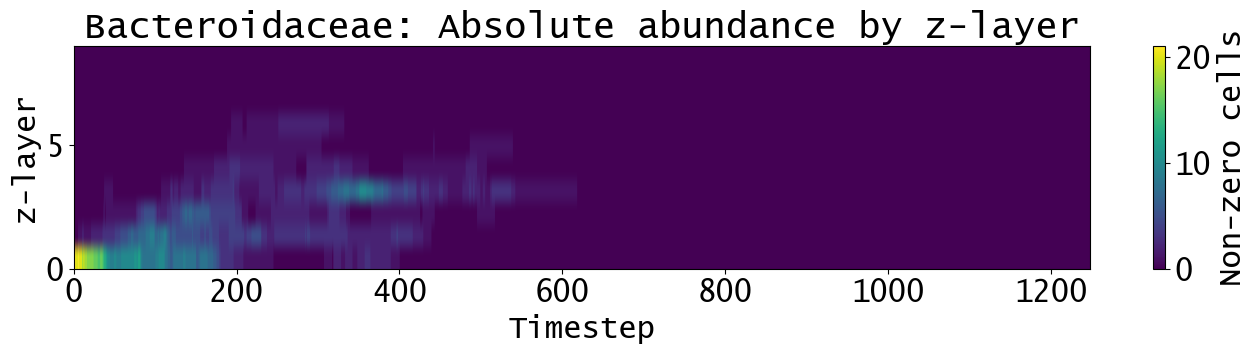

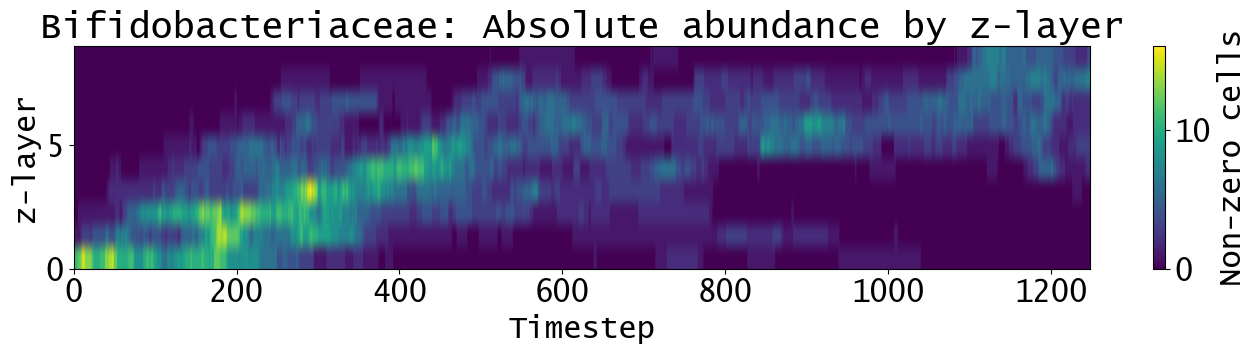

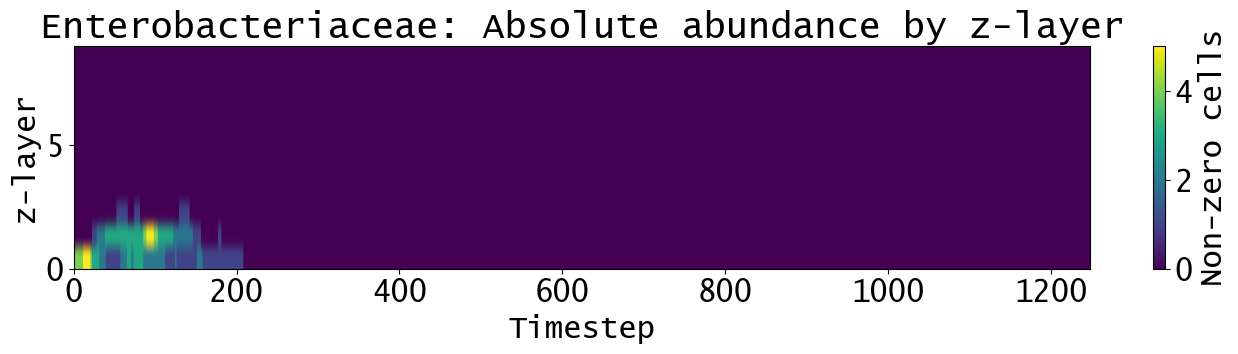

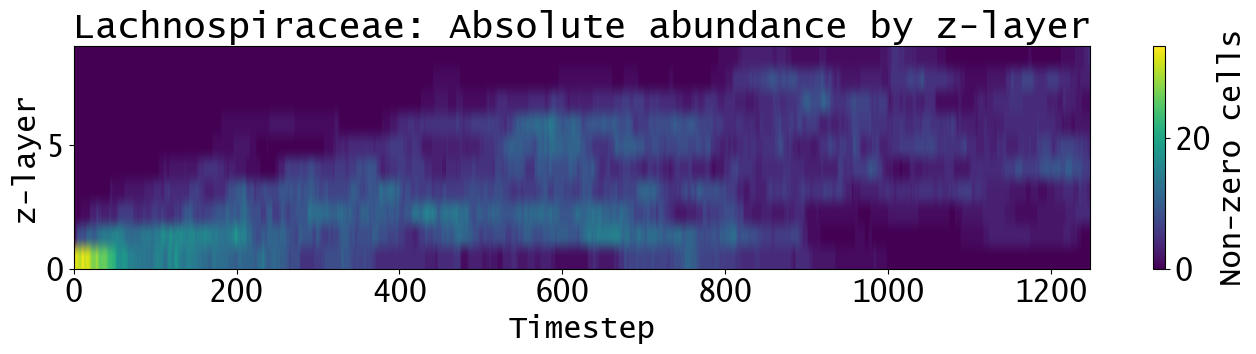

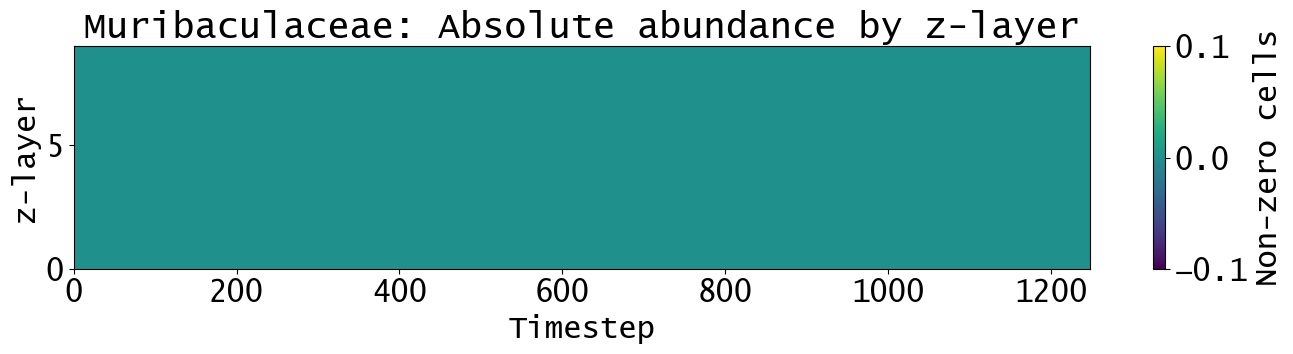

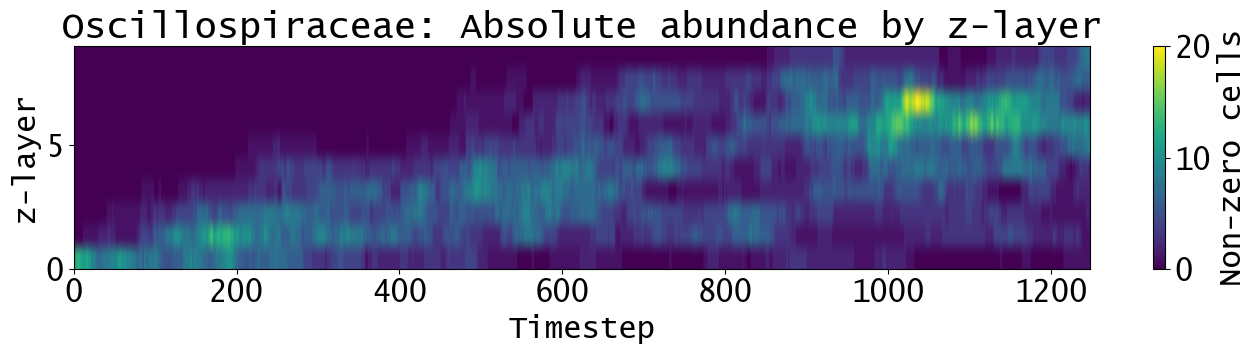

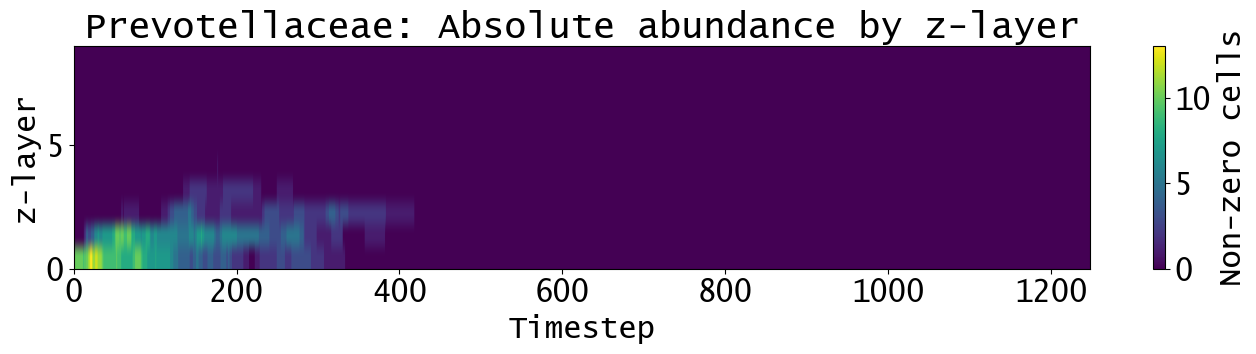

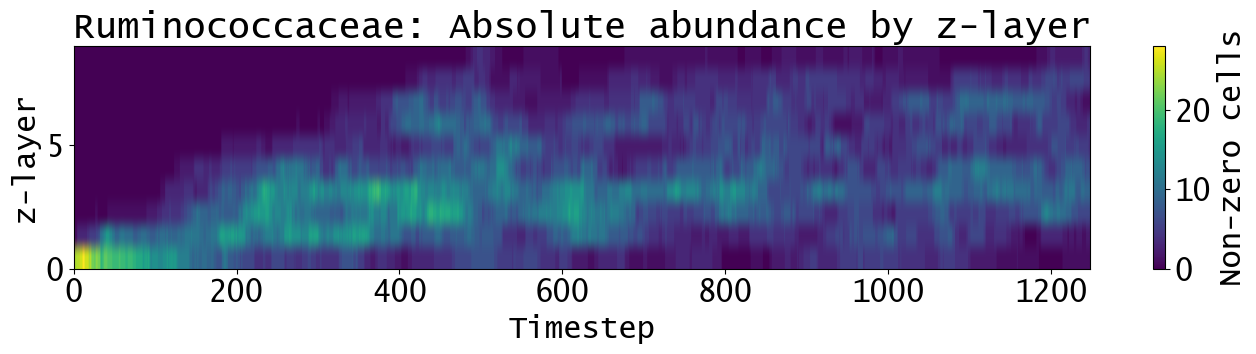

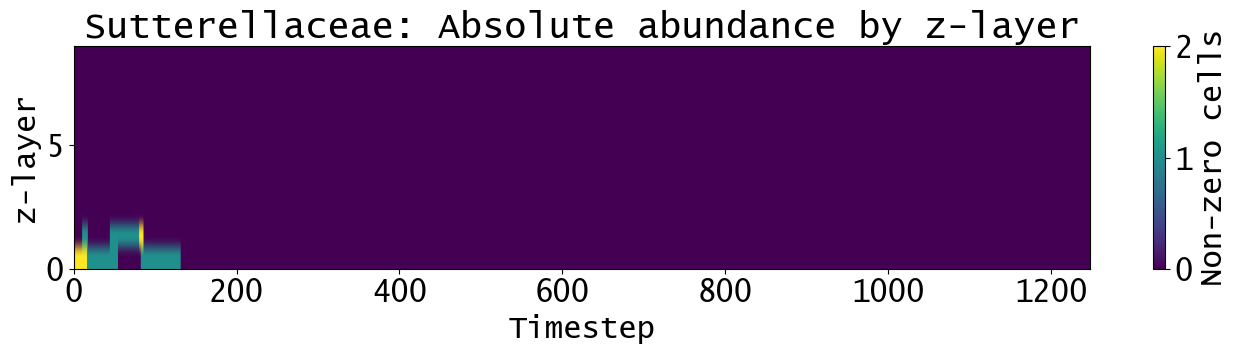

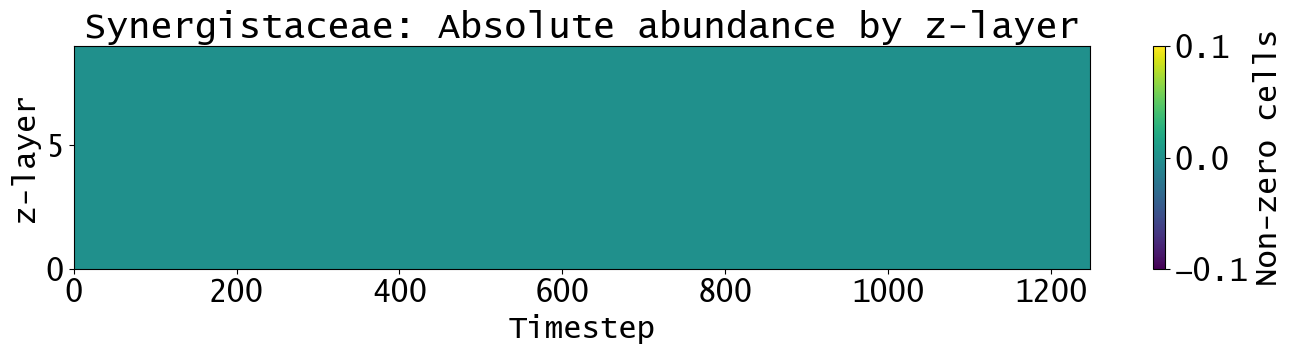

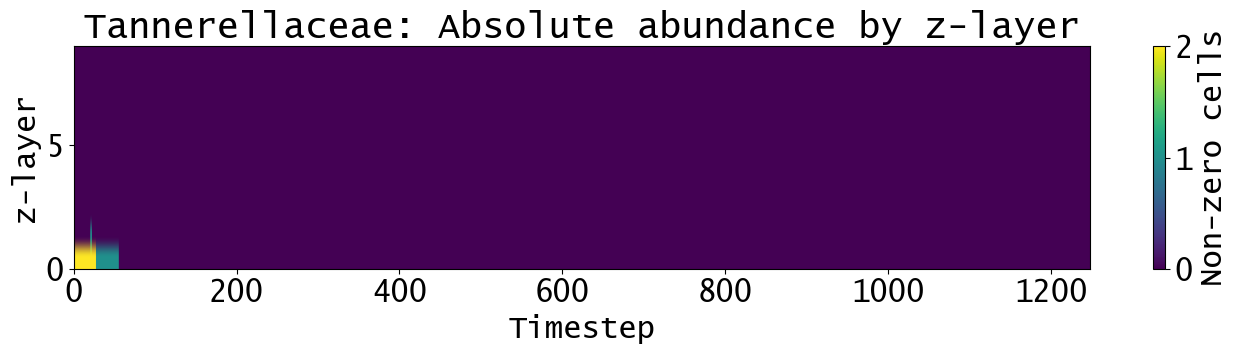

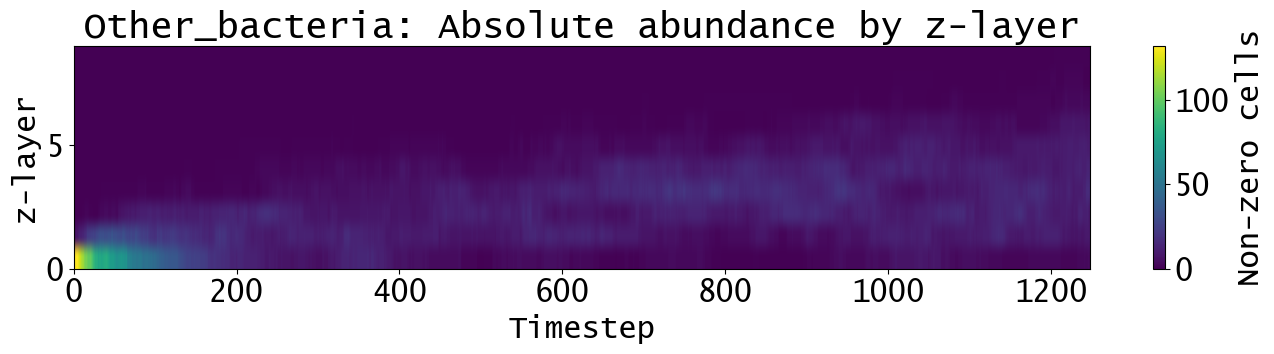

In [7]:
def abundance_by_z_layer(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 5:
        occupied = np.any(arr != 0, axis=-1)
    elif arr.ndim == 4:
        occupied = arr != 0
    else:
        raise ValueError(f"Expected a 4D or 5D tracked array, got shape {arr.shape}")

    return occupied.sum(axis=(1, 2))


for key in selected_keys:
    series = abundance_by_z_layer(tracked[key])

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(
        series.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=(0, series.shape[0] - 1, 0, series.shape[1] - 1),
    )
    ax.set_title(f"{key}: Absolute abundance by z-layer")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("z-layer")
    fig.colorbar(im, ax=ax, label="Non-zero cells")
    plt.tight_layout()
    plt.show()

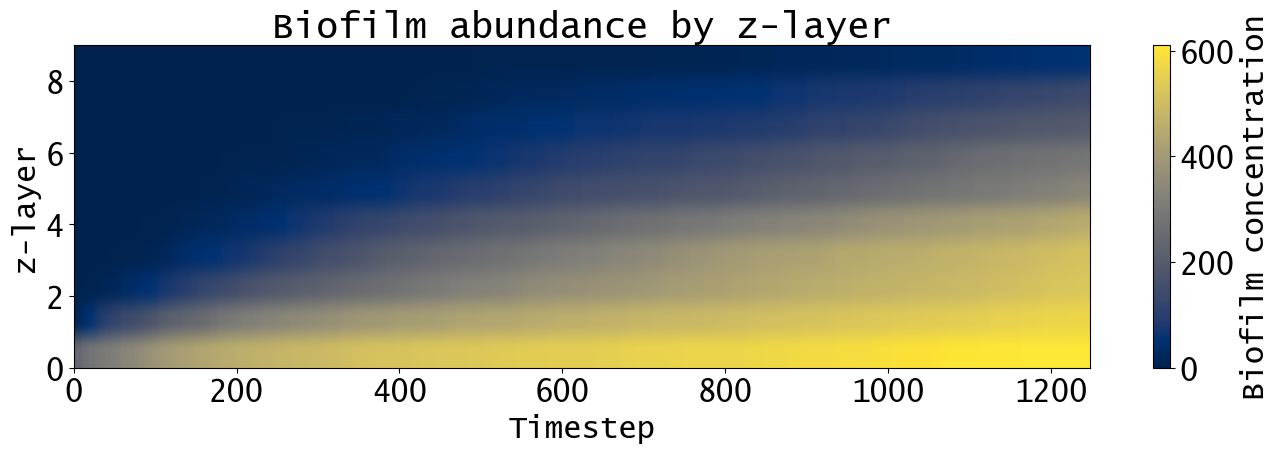

In [8]:
biofilm = tracked.get("biofilm")
if biofilm is None:
    raise KeyError("biofilm field not found in tracked data")

if biofilm.ndim == 5:
    biofilm_total = biofilm.sum(axis=-1)
elif biofilm.ndim == 4:
    biofilm_total = biofilm
else:
    raise ValueError(f"Expected biofilm to be 4D or 5D, got shape {biofilm.shape}")

biofilm_series = biofilm_total.sum(axis=(1, 2))

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    biofilm_series.T,
    aspect="auto",
    origin="lower",
    cmap="cividis",
    extent=(0, biofilm_series.shape[0] - 1, 0, biofilm_series.shape[1] - 1),
)
ax.set_title("Biofilm abundance by z-layer")
ax.set_xlabel("Timestep")
ax.set_ylabel("z-layer")
fig.colorbar(im, ax=ax, label="Biofilm concentration")
plt.tight_layout()
plt.show()

(1249, 50, 50, 10, 6)


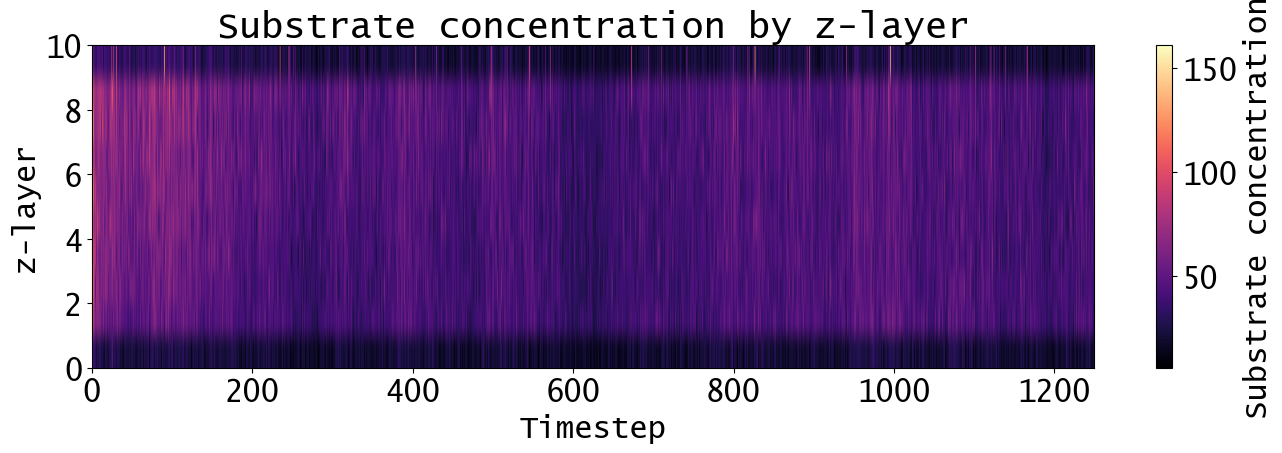

In [9]:
substrate = tracked.get("substrate")
if substrate is None:
    raise KeyError("substrate field not found in tracked data")
print(substrate.shape)
if substrate.ndim == 5:
    substrate_total = substrate.sum(axis=-1)
elif substrate.ndim == 4:
    substrate_total = substrate
else:
    raise ValueError(f"Expected substrate to be 4D or 5D, got shape {substrate.shape}")

substrate_series = substrate_total.sum(axis=(1, 2))

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    substrate_series.T,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=(0, substrate_series.shape[0], 0, substrate_series.shape[1]),
)
ax.set_title("Substrate concentration by z-layer")
ax.set_xlabel("Timestep")
ax.set_ylabel("z-layer")
fig.colorbar(im, ax=ax, label="Substrate concentration")
plt.tight_layout()
plt.show()

# Comparison to dataset

In [10]:
import pandas as pd
# filtered_families = pd.read_csv('../dataset/filtered_families.csv', index_col=0)
filtered_families = pd.read_csv('../dataset/filtered_families_fixed.csv', index_col=0)
df_meta = pd.read_csv('../dataset/meta_final.csv', index_col=0)

In [11]:
num_colors = max(11, filtered_families.shape[1])
color_map = plt.get_cmap('Paired')
colors = [color_map(i % 20) for i in range(filtered_families.shape[1])]
colors2 = ["#5D4EB1", "#8A0EF1", '#173AE8', '#F60971','#F0610F','#B54E4A','#91F40B','#15EACA','#5DA758']

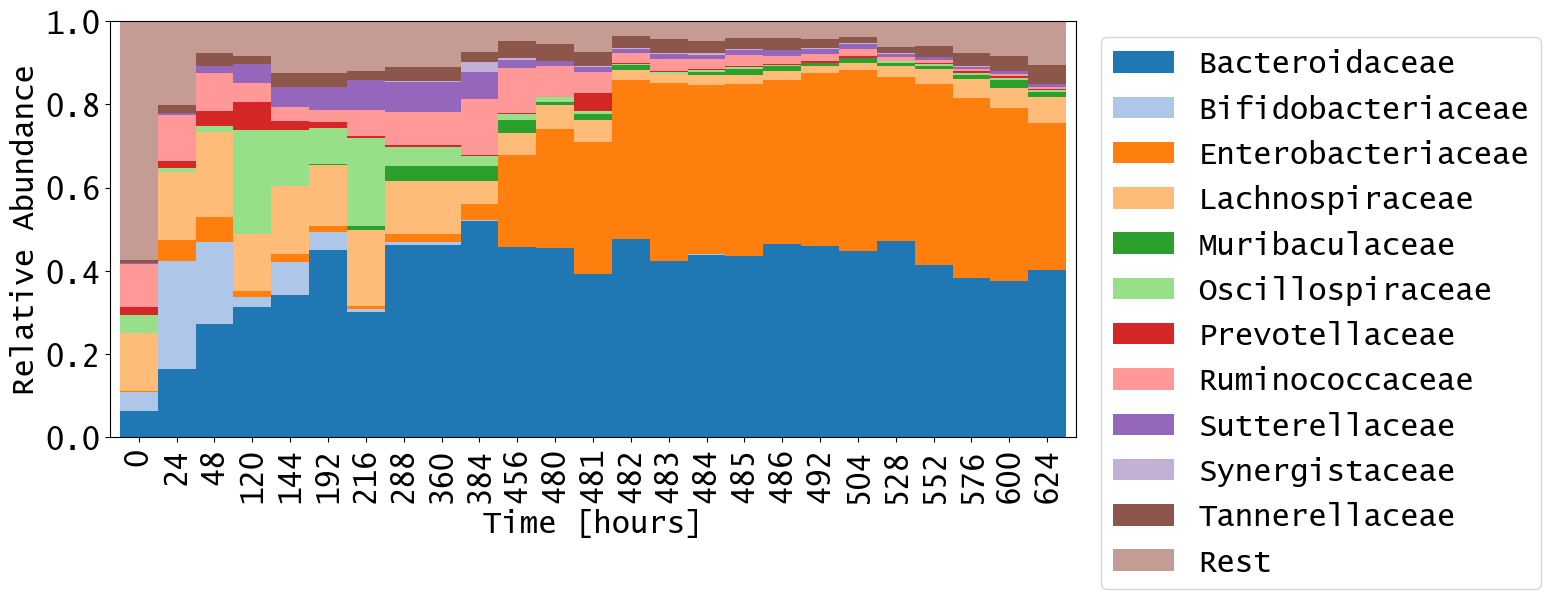

In [12]:
bio_number = 3

# Get sorted index for the specified bioreactor
idx = df_meta[df_meta.Bioreactor == bio_number].sort_values(by=['Bioreactor_run','Day_Steady_state', 'Hour_Treated']).index[:25]

df_meta_nona = df_meta.fillna(0)
# Calculate time values: t = day_steady_state*24 + hours_treated%24
time_df = (df_meta_nona.loc[idx, 'Day_Steady_state'] * 24 + 
               df_meta_nona.loc[idx, 'Hour_Treated'] % 24)
time_values = time_df.values


# Build new xtick labels with Gas and Treatment info
meta_filtered = df_meta.loc[idx]
xtick_labels = [
    f"{int(time_df.at[sample])}" 
    for sample in idx
]

filtered_families_norm = filtered_families.loc[idx].div(filtered_families.loc[idx].sum(axis=1), axis=0)
ax = filtered_families_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(16,6),
    width=1,
    color=STACK_COLORS[:len(selected_keys)]  # Use the same colors as in the previous plot
)
ax.set_xticklabels(xtick_labels, rotation=90)
plt.ylabel('Relative Abundance')
plt.xlabel("Time [hours]")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

In [13]:
sim_data_at_experiment_timesteps = relative_matrix[:,list((time_values*2).astype(int))]
mse = 0
tmp=0
for i in range(25):
    tmp=0
    for j in range(12):
        tmp += (filtered_families_norm.iloc[i][IDX_TO_NAME[j]] - sim_data_at_experiment_timesteps[j,i])**2
    tmp = tmp/12
    print(f'at ts={i}, rmse = {(tmp)**0.5}')
    mse += tmp
mse = mse/26
rmse = mse**0.5
print(rmse)

at ts=0, rmse = 0.020467395394570292
at ts=1, rmse = 0.09161784135042085
at ts=2, rmse = 0.09919271737957519
at ts=3, rmse = 0.11706094963915306
at ts=4, rmse = 0.11136840568514529
at ts=5, rmse = 0.14465573394390002
at ts=6, rmse = 0.122732312989559
at ts=7, rmse = 0.15860670990994807
at ts=8, rmse = 0.15912957400445463
at ts=9, rmse = 0.1808060657345555
at ts=10, rmse = 0.18252486173993324
at ts=11, rmse = 0.19196917154984677
at ts=12, rmse = 0.1848649496806457
at ts=13, rmse = 0.21817180896505306
at ts=14, rmse = 0.21571609836041683
at ts=15, rmse = 0.2139666408378704
at ts=16, rmse = 0.21586918973034847
at ts=17, rmse = 0.2183680734141806
at ts=18, rmse = 0.22105358716082393
at ts=19, rmse = 0.22273425332676358
at ts=20, rmse = 0.218006498926419
at ts=21, rmse = 0.21501317365243466
at ts=22, rmse = 0.20566175310519905
at ts=23, rmse = 0.19910183757361377
at ts=24, rmse = 0.19295241024927595
0.1769243855788832


In [14]:
avg_rmse = 0
for t_bio_number in range(1,4):
    tmp_idx = df_meta[df_meta.Bioreactor == t_bio_number].sort_values(by=['Bioreactor_run','Day_Steady_state', 'Hour_Treated']).index[:25]
    filtered_families_norm_tmp = filtered_families.loc[tmp_idx].div(filtered_families.loc[tmp_idx].sum(axis=1), axis=0)
    mse = 0
    tmp=0
    for i in range(25):
        tmp=0
        for j in range(12):
            tmp += (filtered_families_norm_tmp.iloc[i][IDX_TO_NAME[j]] - sim_data_at_experiment_timesteps[j,i])**2
        tmp = tmp/12
        # print(f'at ts={i}, rmse = {(tmp)**0.5}')
        mse += tmp
    mse = mse/26
    rmse = mse**0.5
    avg_rmse += rmse
avg_rmse = avg_rmse/3
print(avg_rmse)

0.18325840842262528


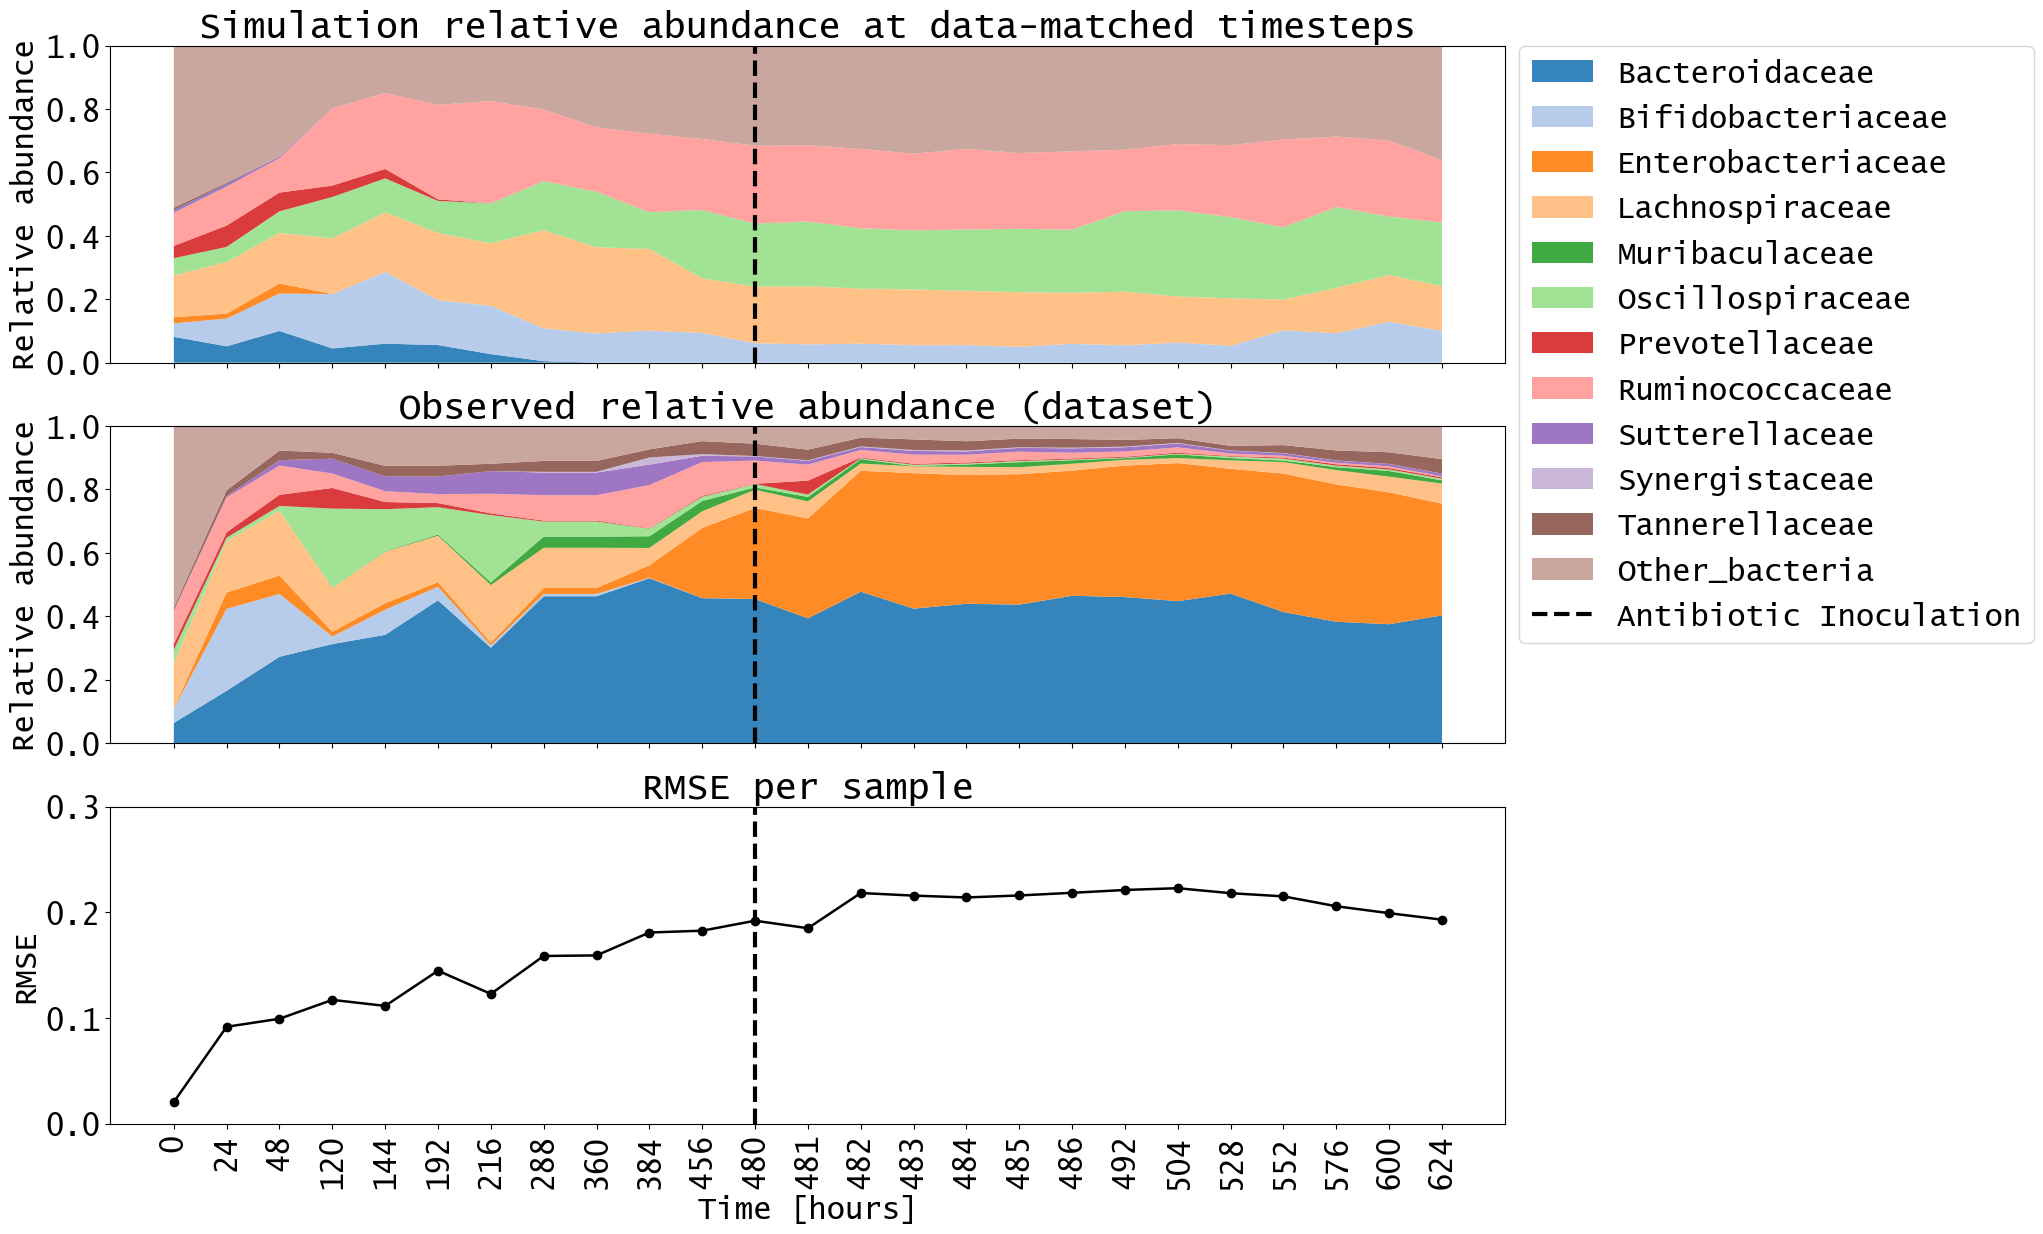

In [15]:
# Build a consistent family order between simulation and dataset.
real_data_keys = []
for j in range(len(selected_keys)):
    mapped = IDX_TO_NAME[j]
    if mapped in filtered_families_norm.columns:
        real_data_keys.append(mapped)
    elif mapped == "Rest" and "Other_bacteria" in filtered_families_norm.columns:
        real_data_keys.append("Other_bacteria")
    else:
        raise KeyError(f"Missing mapped family column in dataset: {mapped}")

sim_step_indices = np.clip((time_values * 2).astype(int), 0, relative_matrix.shape[1] - 1)
sim_sampled = relative_matrix[:, sim_step_indices]
real_sampled = filtered_families_norm[real_data_keys].to_numpy().T

mse_per_sample = (((real_sampled - sim_sampled) ** 2).mean(axis=0))**0.5

x = np.arange(len(sim_step_indices))

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
ax_sim, ax_data, ax_mse = axes

# 1) Simulated relative abundances sampled at timesteps corresponding to the data samples.
ax_sim.stackplot(
    x,
    sim_sampled,
    labels=selected_keys,
    alpha=0.9,
    colors=STACK_COLORS[:len(selected_keys)],
)
ax_sim.set_title("Simulation relative abundance at data-matched timesteps")
ax_sim.set_ylabel("Relative abundance")
ax_sim.set_ylim(0, 1)
if bio_number != 4:
    ax_sim.axvline(11, color="black", linestyle="--", linewidth=3, label="Antibiotic Inoculation") #864 , 85
ax_sim.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)

# 2) Real-data relative abundance stackplot.
ax_data.stackplot(
    x,
    real_sampled,
    labels=real_data_keys,
    alpha=0.9,
    colors=STACK_COLORS[:len(real_data_keys)],
)
ax_data.set_title("Observed relative abundance (dataset)")
ax_data.set_ylabel("Relative abundance")
ax_data.set_ylim(0, 1)
if bio_number != 4:
    ax_data.axvline(11, color="black", linestyle="--", linewidth=3, label="Antibiotic Inoculation") #864 , 85

# 3) Per-sample MSE between simulated and observed compositions.
ax_mse.plot(x, mse_per_sample, marker="o", linewidth=1.8, color="black")
ax_mse.set_title("RMSE per sample")
ax_mse.set_ylabel("RMSE")
ax_mse.set_xlabel("Time [hours]")

ax_mse.set_xticks(x)
ax_mse.set_xticklabels(xtick_labels, rotation=90)
ax_mse.set_yticks([0.0,0.1,0.2,0.3])
if bio_number != 4:
    ax_mse.axvline(11, color="black", linestyle="--", linewidth=3, label="Antibiotic Inoculation") #864 , 85

# plt.tight_layout()
plt.show()